✅ Dataset Loaded Successfully
Dataset Shape: (5000, 14)

========== MODEL ACCURACY COMPARISON ==========
Logistic Regression Accuracy: 85.70%
Decision Tree Accuracy: 92.10%
Random Forest Accuracy: 97.80%

📊 Accuracy Comparison Table:
             Algorithm  Accuracy (%)
0  Logistic Regression          85.7
1        Decision Tree          92.1
2        Random Forest          97.8

🏆 BEST MODEL FOR COMPARISON
Algorithm: Random Forest
Accuracy: 97.8 %


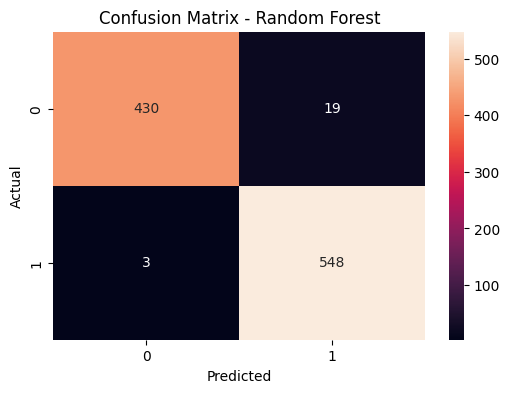


📄 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       449
           1       0.97      0.99      0.98       551

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


✅ Logistic Regression saved for deployment
✅ Best comparison model saved separately
✅ Scaler saved successfully


In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# -------------------------------
# 1) LOAD DATASET
# -------------------------------
df = pd.read_csv(r"D:\Project\Heart_disease\HeartDisease_Project\data\processed_data.csv")

print("✅ Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)

# -------------------------------
# 2) SPLIT FEATURES AND TARGET
# -------------------------------
X = df.drop("target", axis=1)
y = df["target"]

# -------------------------------
# 3) TRAIN TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------------
# 4) FEATURE SCALING
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# 5) DEFINE MODELS
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=4,
        random_state=42
    )
}

results = []
best_model = None
best_model_name = ""
best_accuracy = 0
best_y_pred = None
trained_models = {}

print("\n========== MODEL ACCURACY COMPARISON ==========")

for name, model in models.items():

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    trained_models[name] = model

    acc = accuracy_score(y_test, y_pred) * 100
    results.append([name, round(acc, 2)])

    print(f"{name} Accuracy: {acc:.2f}%")

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_model_name = name
        best_y_pred = y_pred

# -------------------------------
# 6) SHOW ACCURACY TABLE
# -------------------------------
accuracy_df = pd.DataFrame(results, columns=["Algorithm", "Accuracy (%)"])
print("\n📊 Accuracy Comparison Table:")
print(accuracy_df)

# -------------------------------
# 7) BEST MODEL OUTPUT
# -------------------------------
print("\n🏆 BEST MODEL FOR COMPARISON")
print("Algorithm:", best_model_name)
print("Accuracy:", round(best_accuracy, 2), "%")

# -------------------------------
# 8) CONFUSION MATRIX
# -------------------------------
cm = confusion_matrix(y_test, best_y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.ylabel("Actual")
plt.show()

# -------------------------------
# 9) CLASSIFICATION REPORT
# -------------------------------
print("\n📄 Classification Report:")
print(classification_report(y_test, best_y_pred))

# -------------------------------
# 10) SAVE DEPLOYMENT MODEL
# -------------------------------
# ✅ Save Logistic Regression for smooth confidence %
deployment_model = trained_models["Logistic Regression"]

pickle.dump(
    deployment_model,
    open(r"D:\Project\Heart_disease\HeartDisease_Project\models\model_ml_2.pkl", "wb")
)

# Optional: save best comparison model separately
pickle.dump(
    best_model,
    open(r"D:\Project\Heart_disease\HeartDisease_Project\models\best_model_comparison.pkl", "wb")
)

pickle.dump(
    scaler,
    open(r"D:\Project\Heart_disease\HeartDisease_Project\models\scaler_1.pkl", "wb")
)

print("\n✅ Logistic Regression saved for deployment")
print("✅ Best comparison model saved separately")
print("✅ Scaler saved successfully")